# UNGRADED Workbook for In-Class

This notebook is here for you to "code along" during class. 

It will not be graded, so feel free to play around!

In [1]:
import pandas as pd
import requests

url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"
data = pd.read_json(url)
print(data.head())

               time_tag  satellite          flux  observed_flux  \
0  2025-05-06T04:25:00Z         19  1.000000e-09   5.087765e-08   
1  2025-05-06T04:25:00Z         19  7.566322e-07   8.461874e-07   
2  2025-05-06T04:26:00Z         19  1.000000e-09   5.353457e-08   
3  2025-05-06T04:26:00Z         19  7.639804e-07   8.531888e-07   
4  2025-05-06T04:27:00Z         19  1.000000e-09   5.742264e-08   

   electron_correction  electron_contaminaton      energy  
0         6.972603e-08                   True  0.05-0.4nm  
1         8.955516e-08                  False   0.1-0.8nm  
2         6.920122e-08                   True  0.05-0.4nm  
3         8.920841e-08                  False   0.1-0.8nm  
4         7.099791e-08                   True  0.05-0.4nm  


In [2]:
data['time_tag'] = pd.to_datetime(data['time_tag'])
print(data.describe())

       satellite          flux  observed_flux  electron_correction
count     2876.0  2.876000e+03   2.876000e+03         2.876000e+03
mean        19.0  5.202616e-07   6.028285e-07         8.437931e-08
std          0.0  5.725994e-07   5.802176e-07         2.186252e-08
min         19.0  1.000000e-09   2.345483e-08         2.229731e-08
25%         19.0  3.060135e-09   8.296458e-08         6.776035e-08
50%         19.0  6.535545e-07   7.328283e-07         8.735284e-08
75%         19.0  9.050912e-07   1.004862e-06         1.036441e-07
max         19.0  4.539792e-06   4.648959e-06         1.283528e-07


KeyError: 'flux_l'

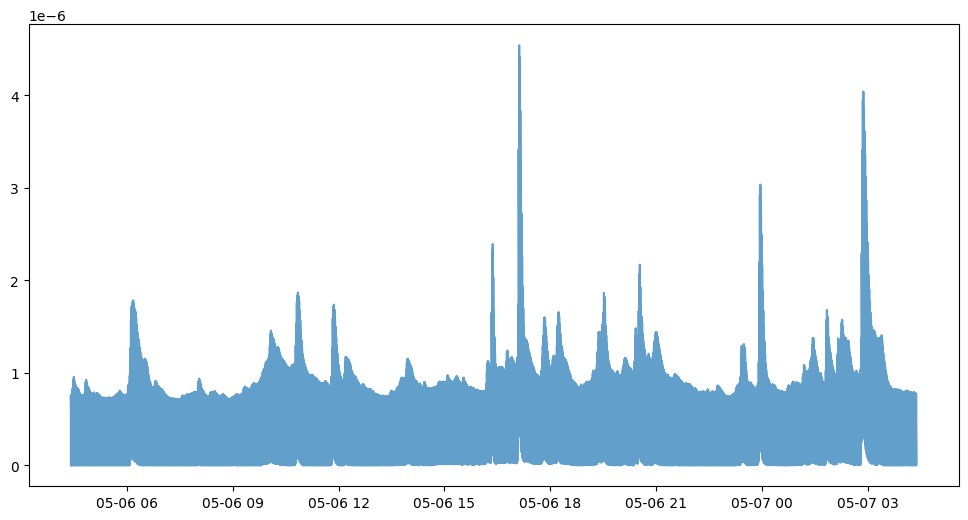

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['time_tag'], data['flux'], label='Short', alpha=0.7)
plt.plot(data['time_tag'], data['flux_l'], label='Long', alpha=0.7)
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Flux (log scale)')
plt.legend()
plt.title('GOES X-ray Flux Over 24 Hours')
plt.show()

In [4]:
print(data.columns)

Index(['time_tag', 'satellite', 'flux', 'observed_flux', 'electron_correction',
       'electron_contaminaton', 'energy'],
      dtype='object')


In [5]:
print(data.head())

pivoted = data.pivot(index='time_tag', columns='energy', values='flux')

print(pivoted.columns)

                   time_tag  satellite          flux  observed_flux  \
0 2025-05-06 04:25:00+00:00         19  1.000000e-09   5.087765e-08   
1 2025-05-06 04:25:00+00:00         19  7.566322e-07   8.461874e-07   
2 2025-05-06 04:26:00+00:00         19  1.000000e-09   5.353457e-08   
3 2025-05-06 04:26:00+00:00         19  7.639804e-07   8.531888e-07   
4 2025-05-06 04:27:00+00:00         19  1.000000e-09   5.742264e-08   

   electron_correction  electron_contaminaton      energy  
0         6.972603e-08                   True  0.05-0.4nm  
1         8.955516e-08                  False   0.1-0.8nm  
2         6.920122e-08                   True  0.05-0.4nm  
3         8.920841e-08                  False   0.1-0.8nm  
4         7.099791e-08                   True  0.05-0.4nm  
Index(['0.05-0.4nm', '0.1-0.8nm'], dtype='object', name='energy')


In [ ]:
plt.figure(figsize=(12,6))
plt.plot(pivoted.index, pivoted['0.05-0.4nm'], label='Short (0.05-0.4nm)', alpha=0.7)
plt.plot(pivoted.index, pivoted['0.1-0.8nm'], label='Long (0.1-0.8nm)', alpha=0.7)
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Flux (Watts/m², log scale)')
plt.legend()
plt.title('GOES X-ray Flux Over 24 Hours')
plt.tight_layout()
plt.show()

In [6]:
flare_threshold = 1e-5  # Example threshold for M-class flares
flares = pivoted[pivoted['0.1-0.8nm'] > flare_threshold]
print(flares)

Empty DataFrame
Columns: [0.05-0.4nm, 0.1-0.8nm]
Index: []


<Axes: xlabel='energy', ylabel='hour'>

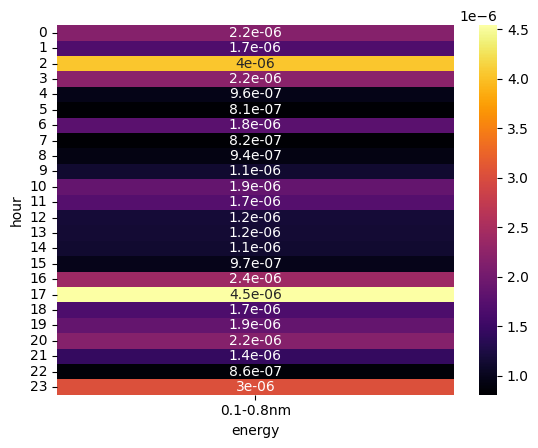

In [7]:
pivoted['hour'] = pivoted.index.hour
hourly_max = pivoted.groupby('hour').max()

import seaborn as sns
sns.heatmap(hourly_max[['0.1-0.8nm']], cmap='inferno', annot=True)

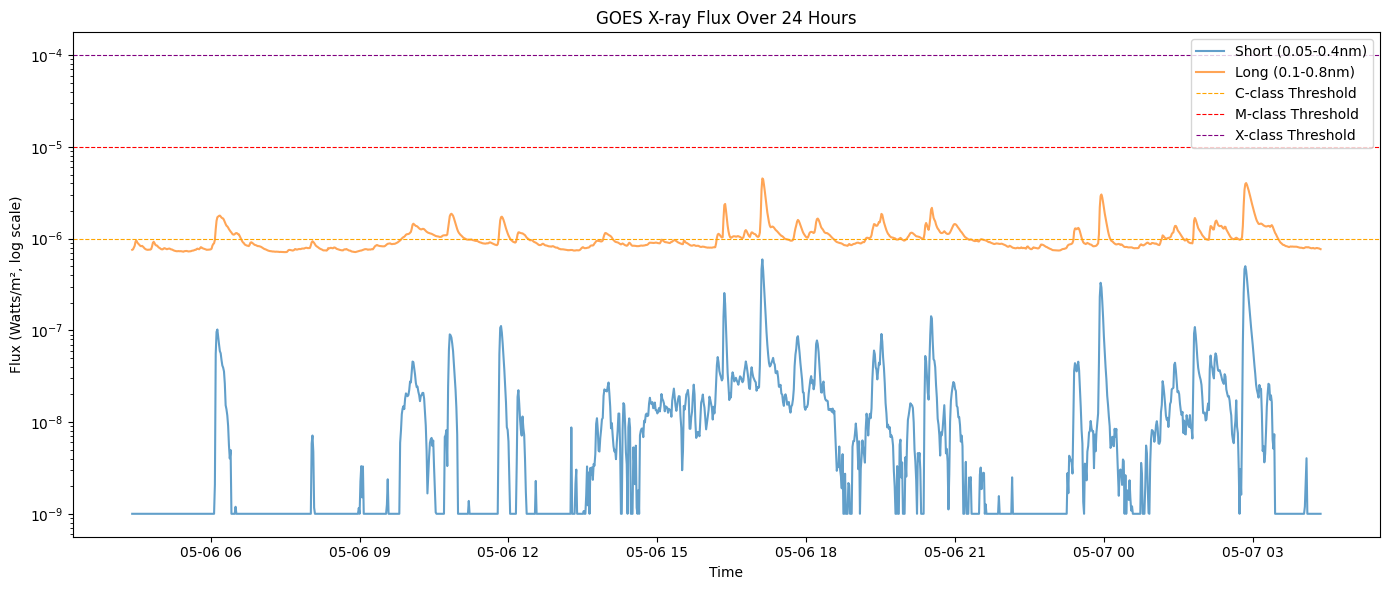

/tmp/ipykernel_153/675854503.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flare_counts.index, y=flare_counts.values, palette='magma')


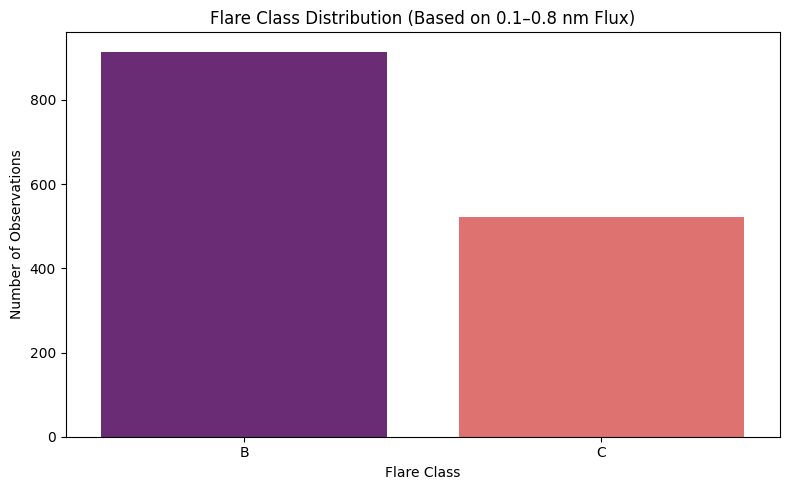

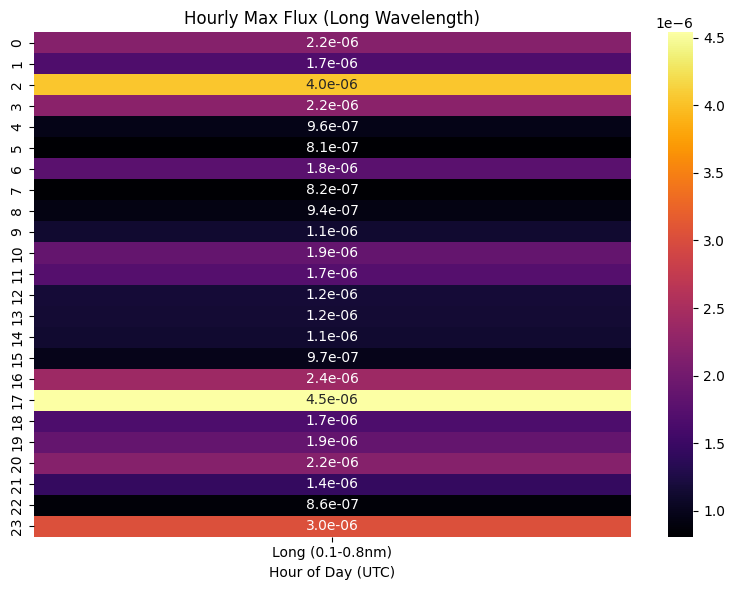

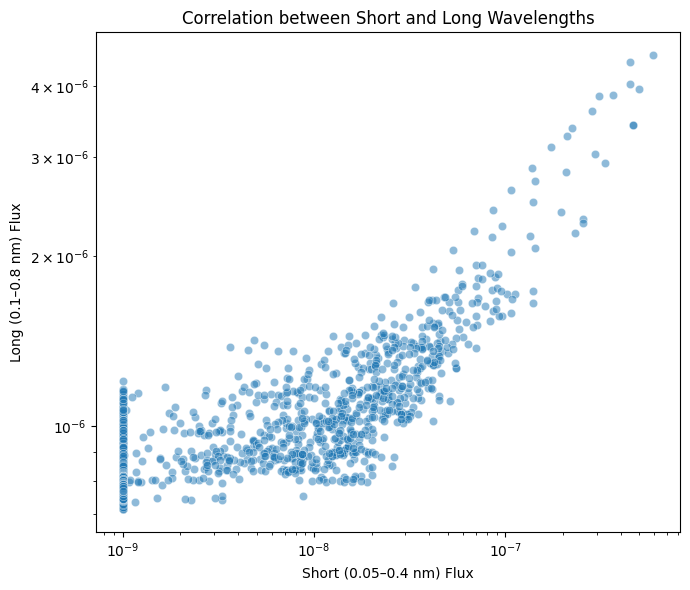

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"
data = pd.read_json(url)

data['time_tag'] = pd.to_datetime(data['time_tag'])

pivoted = data.pivot(index='time_tag', columns='energy', values='flux')

pivoted.columns = ['Short (0.05-0.4nm)', 'Long (0.1-0.8nm)']
pivoted = pivoted.dropna()

plt.figure(figsize=(14, 6))
plt.plot(pivoted.index, pivoted['Short (0.05-0.4nm)'], label='Short (0.05-0.4nm)', alpha=0.7)
plt.plot(pivoted.index, pivoted['Long (0.1-0.8nm)'], label='Long (0.1-0.8nm)', alpha=0.7)
plt.yscale('log')
plt.axhline(1e-6, color='orange', linestyle='--', linewidth=0.8, label='C-class Threshold')
plt.axhline(1e-5, color='red', linestyle='--', linewidth=0.8, label='M-class Threshold')
plt.axhline(1e-4, color='purple', linestyle='--', linewidth=0.8, label='X-class Threshold')
plt.xlabel('Time')
plt.ylabel('Flux (Watts/m², log scale)')
plt.title('GOES X-ray Flux Over 24 Hours')
plt.legend()
plt.tight_layout()
plt.show()

def classify_flare(flux):
    if flux < 1e-7:
        return 'A'
    elif flux < 1e-6:
        return 'B'
    elif flux < 1e-5:
        return 'C'
    elif flux < 1e-4:
        return 'M'
    else:
        return 'X'

flare_classes = pivoted['Long (0.1-0.8nm)'].apply(classify_flare)
flare_counts = flare_classes.value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=flare_counts.index, y=flare_counts.values, palette='magma')
plt.title('Flare Class Distribution (Based on 0.1–0.8 nm Flux)')
plt.xlabel('Flare Class')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()

pivoted['hour'] = pivoted.index.hour
hourly_max = pivoted.groupby('hour').max()

plt.figure(figsize=(8, 6))
sns.heatmap(hourly_max[['Long (0.1-0.8nm)']], cmap='inferno', annot=True, fmt=".1e")
plt.title('Hourly Max Flux (Long Wavelength)')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.scatterplot(x=pivoted['Short (0.05-0.4nm)'], y=pivoted['Long (0.1-0.8nm)'], alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Short (0.05–0.4 nm) Flux')
plt.ylabel('Long (0.1–0.8 nm) Flux')
plt.title('Correlation between Short and Long Wavelengths')
plt.tight_layout()
plt.show()

In [9]:
!pip install cartopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 69.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.9 MB/s eta 0:00:00


/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


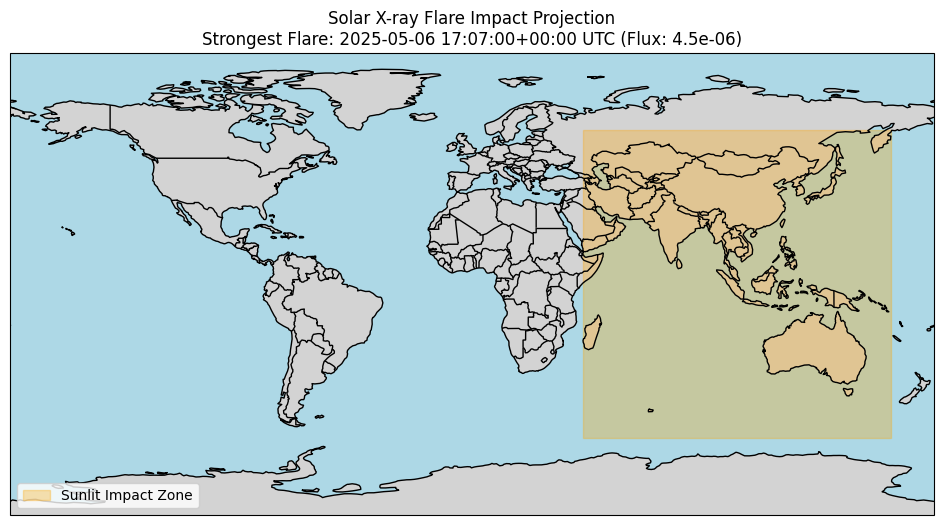

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
from datetime import datetime

url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"
response = requests.get(url)
data = pd.DataFrame(response.json())

data['time_tag'] = pd.to_datetime(data['time_tag'])

long_flux = data[data['energy'] == '0.1-0.8nm'].copy()

strongest = long_flux.loc[long_flux['flux'].idxmax()]
flare_time = strongest['time_tag']
flare_flux = strongest['flux']

utc_hour = flare_time.hour + flare_time.minute / 60
subsolar_lon = -15 * utc_hour  # Earth rotates 15° per hour

plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

impact_lon_min = subsolar_lon - 60
impact_lon_max = subsolar_lon + 60
ax.add_patch(plt.Rectangle((impact_lon_min, -60), 120, 120,
                           transform=ccrs.PlateCarree(), color='orange', alpha=0.3,
                           label='Sunlit Impact Zone'))

plt.title(f'Solar X-ray Flare Impact Projection\nStrongest Flare: {flare_time} UTC (Flux: {flare_flux:.1e})')
plt.legend(loc='lower left')
plt.show()


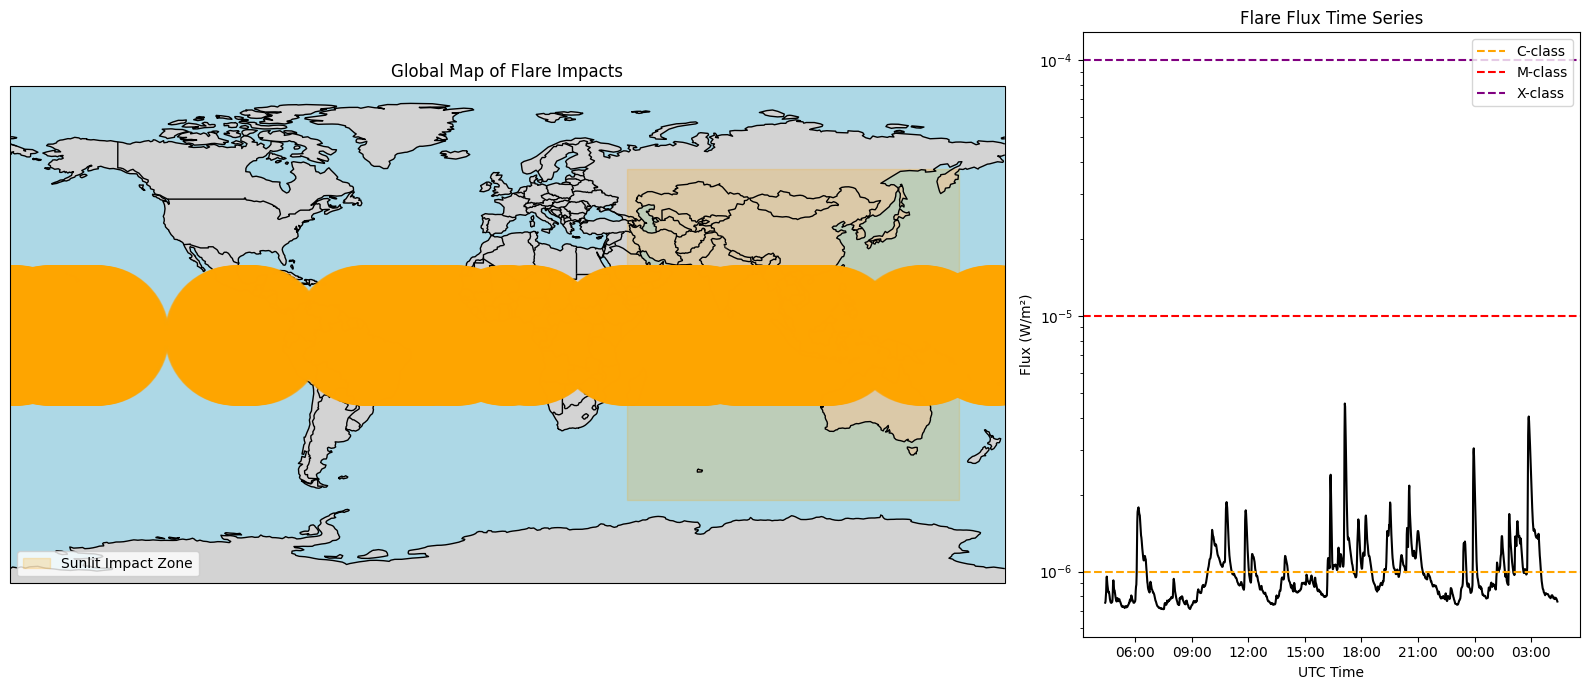

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import numpy as np
from datetime import datetime

url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"
response = requests.get(url)
data = pd.DataFrame(response.json())
data['time_tag'] = pd.to_datetime(data['time_tag'])

long_flux = data[data['energy'] == '0.1-0.8nm'].copy()

def flare_color(flux):
    if flux < 1e-6:
        return 'yellow'
    elif flux < 1e-5:
        return 'orange'
    elif flux < 1e-4:
        return 'red'
    else:
        return 'purple'

fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

ax_map = plt.subplot(gs[0], projection=ccrs.PlateCarree())
ax_map.set_global()
ax_map.coastlines()
ax_map.add_feature(cfeature.BORDERS)
ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
ax_map.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax_map.set_title('Global Map of Flare Impacts')

strong_flares = long_flux[long_flux['flux'] > 1e-6]
for _, row in strong_flares.iterrows():
    t = row['time_tag']
    flux = row['flux']
    lon = -15 * (t.hour + t.minute / 60)
    color = flare_color(flux)
    size = min(flux * 1e8, 100)
    ax_map.plot(lon, 0, marker='o', color=color, markersize=size,
                alpha=0.5, transform=ccrs.PlateCarree())

strongest = strong_flares.loc[strong_flares['flux'].idxmax()]
t_max = strongest['time_tag']
subsolar_lon = -15 * (t_max.hour + t_max.minute / 60)
ax_map.add_patch(plt.Rectangle((subsolar_lon - 60, -60), 120, 120,
                transform=ccrs.PlateCarree(), color='orange', alpha=0.2,
                label='Sunlit Impact Zone'))
ax_map.legend(loc='lower left')

ax_time = plt.subplot(gs[1])
ax_time.plot(long_flux['time_tag'], long_flux['flux'], color='black')
ax_time.set_yscale('log')
ax_time.set_title('Flare Flux Time Series')
ax_time.set_xlabel('UTC Time')
ax_time.set_ylabel('Flux (W/m²)')
ax_time.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_time.axhline(1e-6, color='orange', linestyle='--', label='C-class')
ax_time.axhline(1e-5, color='red', linestyle='--', label='M-class')
ax_time.axhline(1e-4, color='purple', linestyle='--', label='X-class')
ax_time.legend()

plt.tight_layout()
plt.show()

/opt/conda/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:527: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/tmp/ipykernel_153/1633833351.py:80: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:527: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/opt/conda/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  return super().draw(renderer=renderer, **kwargs)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


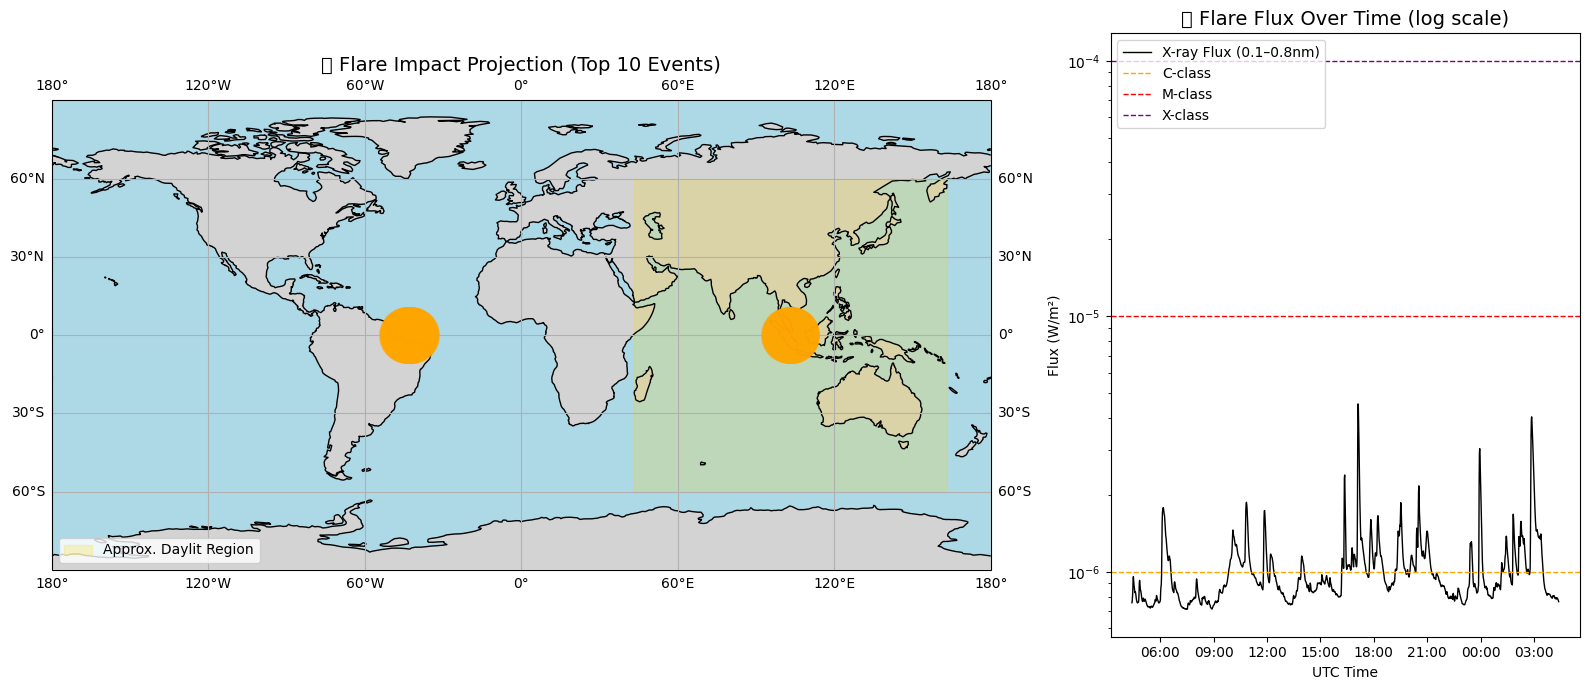

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import numpy as np
from datetime import datetime

url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"
response = requests.get(url)
data = pd.DataFrame(response.json())

data['time_tag'] = pd.to_datetime(data['time_tag'])
long_flux = data[data['energy'] == '0.1-0.8nm'].copy()

strong_flares = long_flux.sort_values(by='flux', ascending=False).head(10)

def flare_color(flux):
    if flux < 1e-6:
        return 'yellow'
    elif flux < 1e-5:
        return 'orange'
    elif flux < 1e-4:
        return 'red'
    else:
        return 'purple'

fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

ax_map = plt.subplot(gs[0], projection=ccrs.PlateCarree())
ax_map.set_global()
ax_map.coastlines()
ax_map.gridlines(draw_labels=True)
ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
ax_map.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax_map.set_title('🌍 Flare Impact Projection (Top 10 Events)', fontsize=14)

for _, row in strong_flares.iterrows():
    flare_time = row['time_tag']
    flux = row['flux']
    lon = -15 * (flare_time.hour + flare_time.minute / 60)
    color = flare_color(flux)
    size = np.clip(flux * 1e8, 10, 40)
    ax_map.plot(lon, 0, marker='o', color=color, markersize=size, 
                transform=ccrs.PlateCarree(), alpha=0.6)

strongest = strong_flares.iloc[0]
strongest_time = strongest['time_tag']
subsolar_lon = -15 * (strongest_time.hour + strongest_time.minute / 60)
ax_map.add_patch(plt.Rectangle((subsolar_lon - 60, -60), 120, 120,
    transform=ccrs.PlateCarree(), color='gold', alpha=0.2, label='Approx. Daylit Region'))
ax_map.legend(loc='lower left')

ax_time = plt.subplot(gs[1])
ax_time.plot(long_flux['time_tag'], long_flux['flux'], color='black', label='X-ray Flux (0.1–0.8nm)', linewidth=1)
ax_time.set_yscale('log')
ax_time.set_title('📈 Flare Flux Over Time (log scale)', fontsize=14)
ax_time.set_xlabel('UTC Time')
ax_time.set_ylabel('Flux (W/m²)')
ax_time.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax_time.axhline(1e-6, color='orange', linestyle='--', linewidth=1, label='C-class')
ax_time.axhline(1e-5, color='red', linestyle='--', linewidth=1, label='M-class')
ax_time.axhline(1e-4, color='purple', linestyle='--', linewidth=1, label='X-class')
ax_time.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
!pip install ipywidgets

/opt/conda/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:527: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/tmp/ipykernel_153/1799075772.py:93: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:527: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/opt/conda/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  return super().draw(renderer=renderer, **kwargs)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


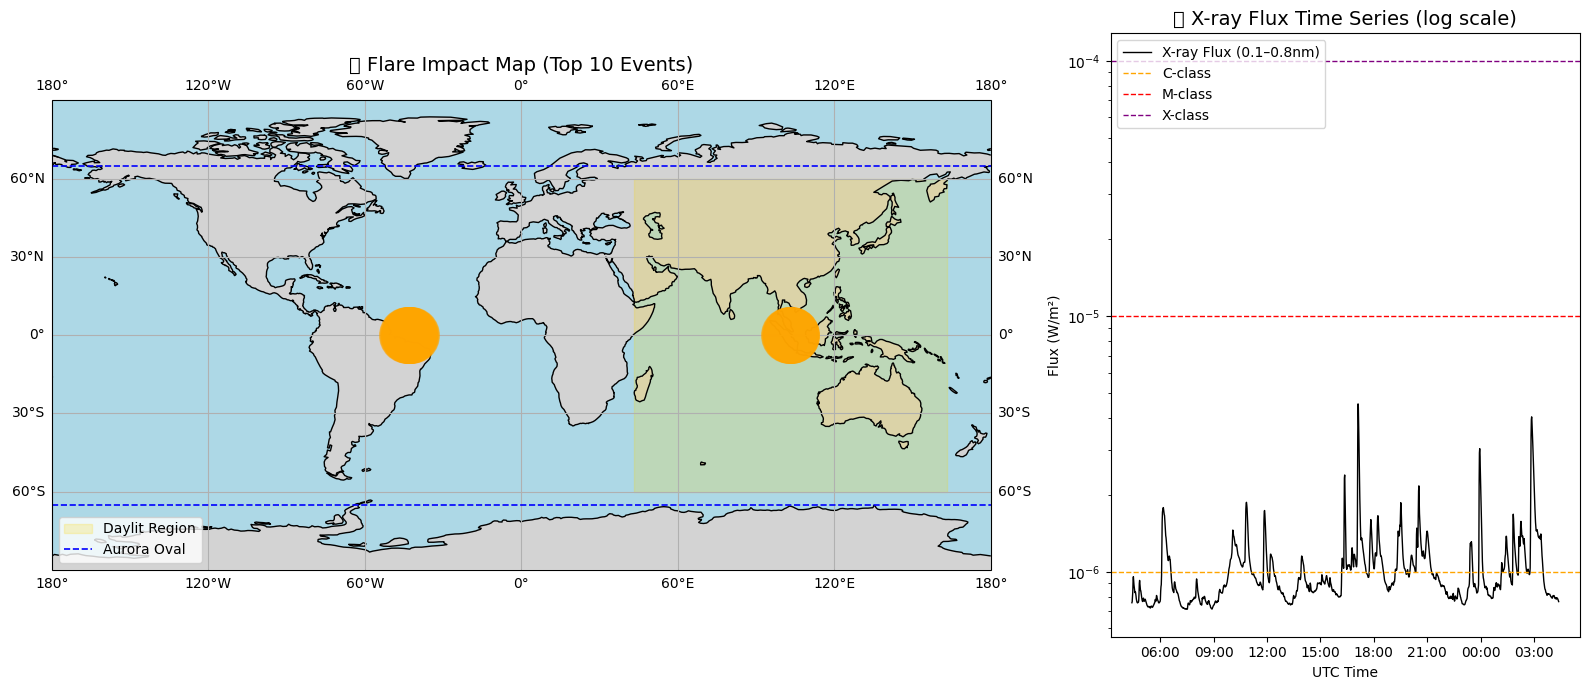

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import numpy as np

show_aurora = True  # Change to False to hide aurora zones

url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"
response = requests.get(url)
data = pd.DataFrame(response.json())

data['time_tag'] = pd.to_datetime(data['time_tag'])
long_flux = data[data['energy'] == '0.1-0.8nm'].copy()
strong_flares = long_flux.sort_values(by='flux', ascending=False).head(10)

def flare_color(flux):
    if flux < 1e-6:
        return 'yellow'
    elif flux < 1e-5:
        return 'orange'
    elif flux < 1e-4:
        return 'red'
    else:
        return 'purple'

fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

ax_map = plt.subplot(gs[0], projection=ccrs.PlateCarree())
ax_map.set_global()
ax_map.coastlines()
ax_map.gridlines(draw_labels=True)
ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
ax_map.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax_map.set_title(' Flare Impact Map (Top 10 Events)', fontsize=14)

for _, row in strong_flares.iterrows():
    flare_time = row['time_tag']
    flux = row['flux']
    lon = -15 * (flare_time.hour + flare_time.minute / 60)
    color = flare_color(flux)
    size = np.clip(flux * 1e8, 10, 40)
    ax_map.plot(lon, 0, marker='o', color=color, markersize=size,
                transform=ccrs.PlateCarree(), alpha=0.6)

strongest = strong_flares.iloc[0]
strongest_time = strongest['time_tag']
subsolar_lon = -15 * (strongest_time.hour + strongest_time.minute / 60)
ax_map.add_patch(plt.Rectangle((subsolar_lon - 60, -60), 120, 120,
                               transform=ccrs.PlateCarree(), color='gold', alpha=0.2,
                               label='Daylit Region'))

if show_aurora:
    for lat in [65, -65]:
        ax_map.plot(np.linspace(-180, 180, 500), [lat]*500,
                    transform=ccrs.Geodetic(), linestyle='--',
                    color='blue', linewidth=1.2,
                    label='Aurora Oval' if lat == 65 else None)

ax_map.legend(loc='lower left')

ax_time = plt.subplot(gs[1])
ax_time.plot(long_flux['time_tag'], long_flux['flux'], color='black',
             label='X-ray Flux (0.1–0.8nm)', linewidth=1)
ax_time.set_yscale('log')
ax_time.set_title('📈 X-ray Flux Time Series (log scale)', fontsize=14)
ax_time.set_xlabel('UTC Time')
ax_time.set_ylabel('Flux (W/m²)')
ax_time.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax_time.axhline(1e-6, color='orange', linestyle='--', linewidth=1, label='C-class')
ax_time.axhline(1e-5, color='red', linestyle='--', linewidth=1, label='M-class')
ax_time.axhline(1e-4, color='purple', linestyle='--', linewidth=1, label='X-class')
ax_time.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import numpy as np
from ipywidgets import interact, IntSlider, Checkbox

url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"
response = requests.get(url)
data = pd.DataFrame(response.json())

data['time_tag'] = pd.to_datetime(data['time_tag'])
long_flux = data[data['energy'] == '0.1-0.8nm'].copy()
long_flux_sorted = long_flux.sort_values(by='flux', ascending=False)

def flare_color(flux):
    if flux < 1e-6:
        return 'yellow'
    elif flux < 1e-5:
        return 'orange'
    elif flux < 1e-4:
        return 'red'
    else:
        return 'purple'

def plot_interactive_flare_map(top_n=5, show_aurora=True):
    top_flares = long_flux_sorted.head(top_n)

    fig = plt.figure(figsize=(16, 7))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

    ax_map = plt.subplot(gs[0], projection=ccrs.PlateCarree())
    ax_map.set_global()
    ax_map.coastlines()
    ax_map.gridlines(draw_labels=True)
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
    ax_map.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax_map.set_title(f' Top {top_n} Flare Impact Map', fontsize=14)

    for _, row in top_flares.iterrows():
        flare_time = row['time_tag']
        flux = row['flux']
        lon = -15 * (flare_time.hour + flare_time.minute / 60)
        color = flare_color(flux)
        size = np.clip(flux * 1e8, 10, 40)
        ax_map.plot(lon, 0, marker='o', color=color, markersize=size,
                    transform=ccrs.PlateCarree(), alpha=0.6)

    strongest = top_flares.iloc[0]
    subsolar_lon = -15 * (strongest['time_tag'].hour + strongest['time_tag'].minute / 60)
    ax_map.add_patch(plt.Rectangle((subsolar_lon - 60, -60), 120, 120,
                                   transform=ccrs.PlateCarree(), color='gold', alpha=0.2,
                                   label='Daylit Region'))

    if show_aurora:
        for lat in [65, -65]:
            ax_map.plot(np.linspace(-180, 180, 500), [lat]*500,
                        transform=ccrs.Geodetic(), linestyle='--',
                        color='blue', linewidth=1.2,
                        label='Aurora Oval' if lat == 65 else None)

    ax_map.legend(loc='lower left')

    ax_time = plt.subplot(gs[1])
    ax_time.plot(long_flux['time_tag'], long_flux['flux'], color='black',
                 label='X-ray Flux (0.1–0.8nm)', linewidth=1)
    ax_time.set_yscale('log')
    ax_time.set_title(' X-ray Flux Time Series (log scale)', fontsize=14)
    ax_time.set_xlabel('UTC Time')
    ax_time.set_ylabel('Flux (W/m²)')
    ax_time.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    ax_time.axhline(1e-6, color='orange', linestyle='--', linewidth=1, label='C-class')
    ax_time.axhline(1e-5, color='red', linestyle='--', linewidth=1, label='M-class')
    ax_time.axhline(1e-4, color='purple', linestyle='--', linewidth=1, label='X-class')
    ax_time.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

interact(plot_interactive_flare_map,
         top_n=IntSlider(value=5, min=1, max=20, step=1, description='Top N Flares'),
         show_aurora=Checkbox(value=True, description='Show Aurora Zones'));

interactive(children=(IntSlider(value=5, description='Top N Flares', max=20, min=1), Checkbox(value=True, desc…